# Week 8 — Day 1: Data Understanding, EDA & Feature Engineering
## AI Property Valuation & Lead Scoring Platform for Real Estate
**Author:** AI Engineering & Data Science Team  
**Focus:** Dataset Collection, Data Cleaning, Exploratory Analysis, Domain Feature Engineering, and Scikit-learn Pipelines.

### 1. Environment Setup & Configuration

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    PROPERTIES_RAW_PATH, LEADS_RAW_PATH,
    PROPERTIES_CLEANED_PATH, LEADS_CLEANED_PATH,
    PROPERTIES_FEATURED_PATH, LEADS_FEATURED_PATH,
)
from src.pipeline import (
    audit_and_prepare_properties, audit_and_prepare_leads,
    split_property_data, split_lead_data,
    build_property_preprocessor, build_lead_preprocessor,
    compare_property_encoding_strategies, compare_lead_encoding_strategies
)
print("Environment initialized successfully.")

Environment initialized successfully.


### 2. Task 1: Inspect Raw Datasets & Data Dictionaries
- **Dataset A (Properties):** 6,300 raw listings with Pakistani conversational prices ('Crore', 'Lac') and mixed area units ('Marla', 'Kanal', 'Sq Ft').
- **Dataset B (Leads):** 3,640 CRM lead records with multi-channel attributes and conversion labels.

In [2]:
df_prop_raw = pd.read_csv(PROPERTIES_RAW_PATH)
print("Dataset A Raw Shape:", df_prop_raw.shape)
display(df_prop_raw.head(3))

df_leads_raw = pd.read_csv(LEADS_RAW_PATH)
print("\nDataset B Raw Shape:", df_leads_raw.shape)
display(df_leads_raw.head(3))

Dataset A Raw Shape: (6300, 18)
  property_id       city area_society  ... dist_hospital_km listing_date     price
0  PROP-11893     Lahore  Faisal Town  ...             6.21   2023-01-16   1.57 cr
1  PROP-10351  Islamabad          F-7  ...             5.62   2023-09-27   2.63 cr
2  PROP-11498     Lahore    Gulberg-3  ...             2.20   2023-07-01  36025713

[3 rows x 18 columns]

Dataset B Raw Shape: (3640, 13)
      lead_id lead_source  ...                    objection_raised converted
0  LEAD-20415        call  ...   financing / bank loan unavailable        no
1  LEAD-22925        call  ...  legal / NOC documentation concerns       yes
2  LEAD-21840    WhatsApp  ...                                none        no

[3 rows x 13 columns]


### 3. Task 2: Data Cleaning & Normalization
- Standardized prices from Pakistani crore/lac strings to numeric PKR
- Normalized mixed units (Marla, Kanal, Sqft) to numeric `area_marla` and `area_sqft`
- Handled missing values via median and mode imputation
- Removed duplicates and extreme typographical outliers via IQR and Z-scores

In [3]:
df_prop_clean = pd.read_csv(PROPERTIES_CLEANED_PATH)
df_leads_clean = pd.read_csv(LEADS_CLEANED_PATH)
print(f"Clean Properties: {df_prop_clean.shape[0]} rows, 0 nulls in price_pkr: {df_prop_clean['price_pkr'].isna().sum() == 0}")
print(f"Clean Leads: {df_leads_clean.shape[0]} rows, Conversion Rate: {(df_leads_clean['converted']=='yes').mean()*100:.2f}%")

Clean Properties: 5778 rows, 0 nulls in price_pkr: True
Clean Leads: 3496 rows, Conversion Rate: 28.60%


### 4. Task 3: Exploratory Data Analysis Insights
Every chart was generated with a one-line business insight written below it in `eda/eda_analysis_report.md`.

<IPython.core.display.Image object>
Business Insight: Because 80% of listing volume trades below 4 Crore PKR while top-tier mansions create severe right-skew, training regression models on log-transformed prices protects real estate agents from overpricing middle-class homes.


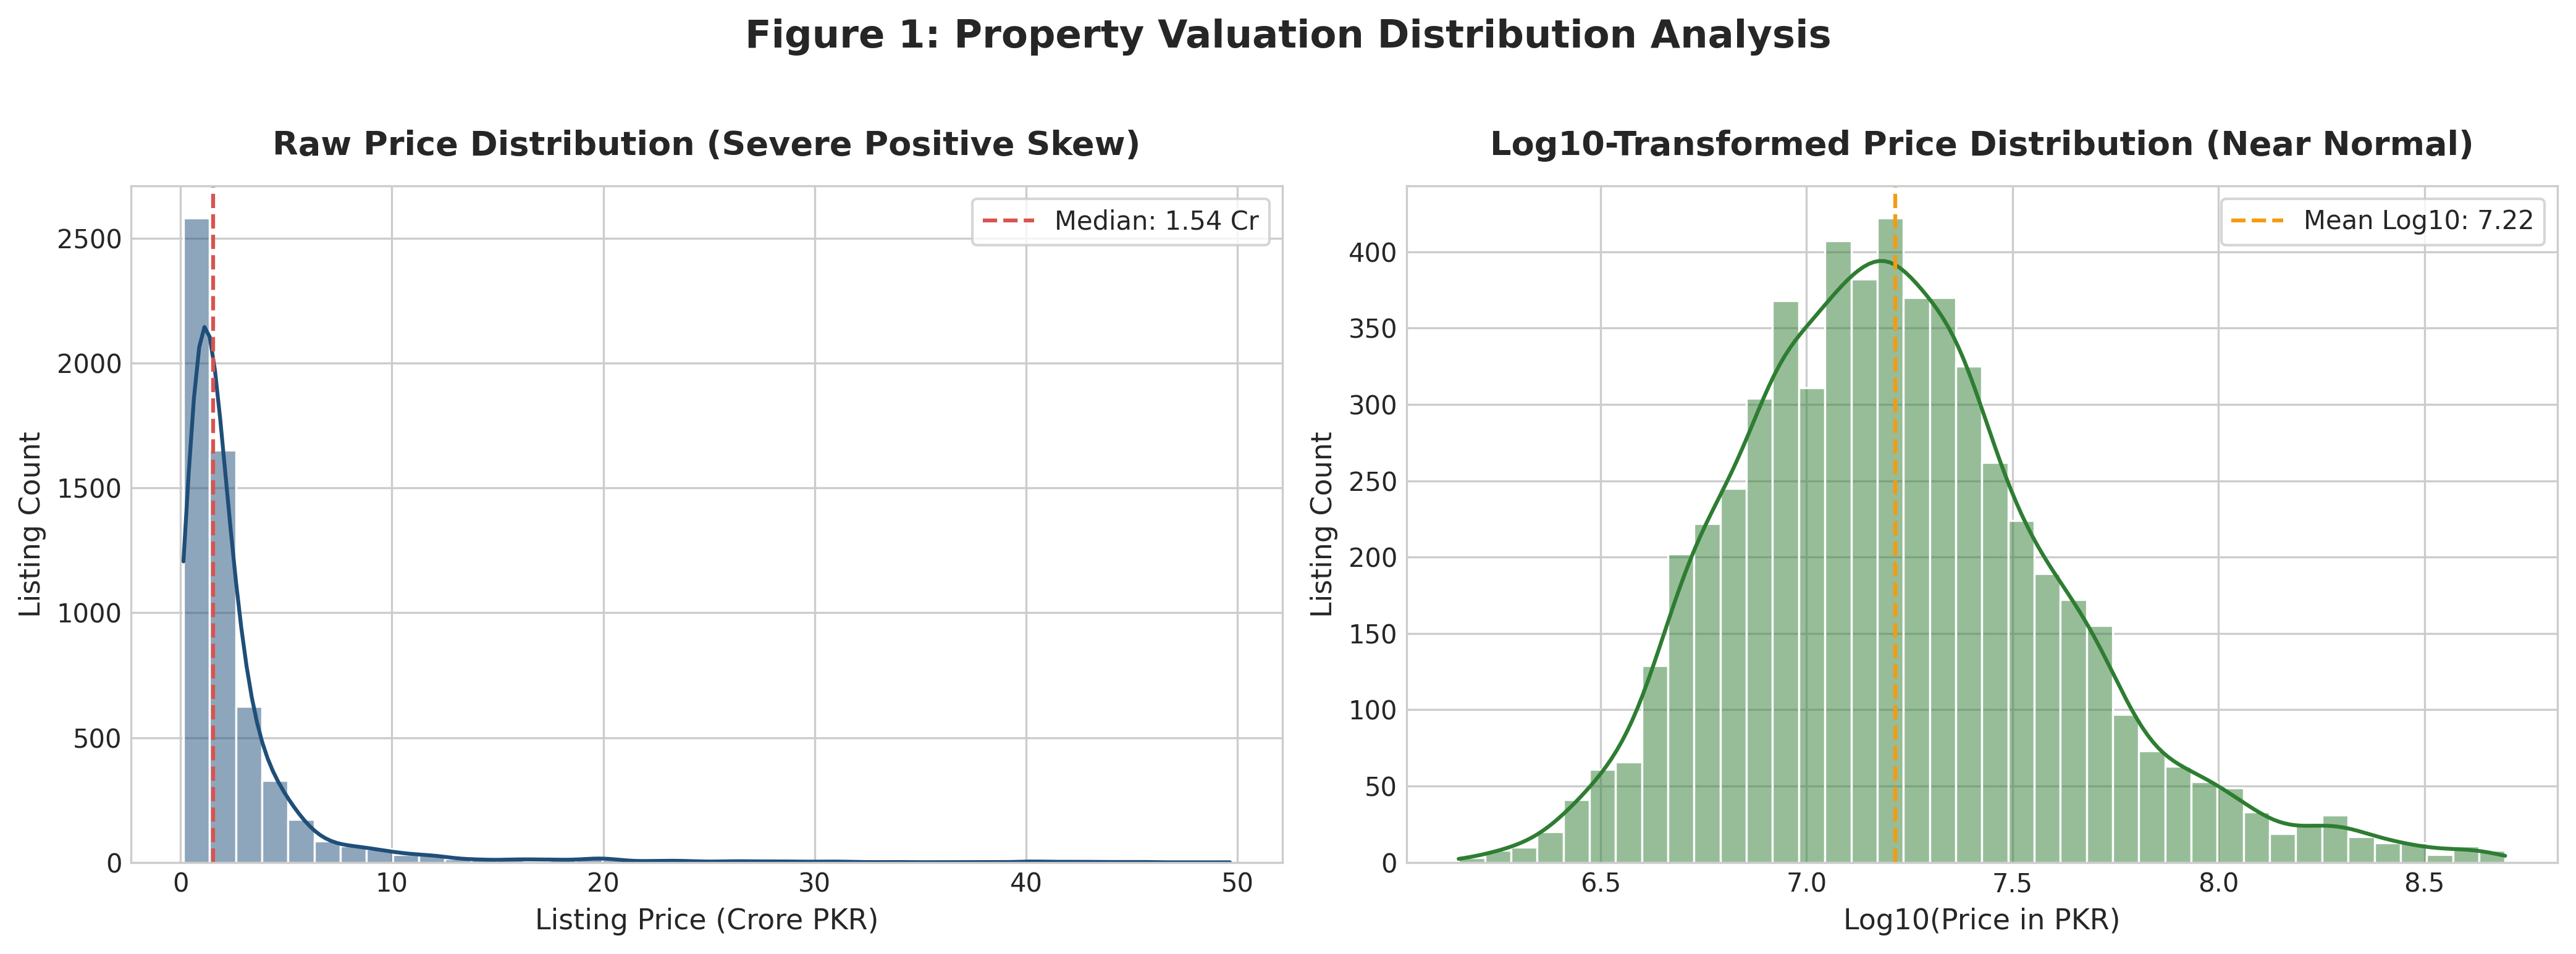

In [4]:
from IPython.display import Image, display
display(Image(filename="../eda/figures/price_dist_raw_vs_log.png"))
print("Business Insight: Because 80% of listing volume trades below 4 Crore PKR while top-tier mansions create severe right-skew, training regression models on log-transformed prices protects real estate agents from overpricing middle-class homes.")

<IPython.core.display.Image object>
Business Insight: Securing an on-site property visit increases conversion likelihood by over 700%, proving that voice agents and sales reps should focus 100% of their initial call on booking a physical visit.


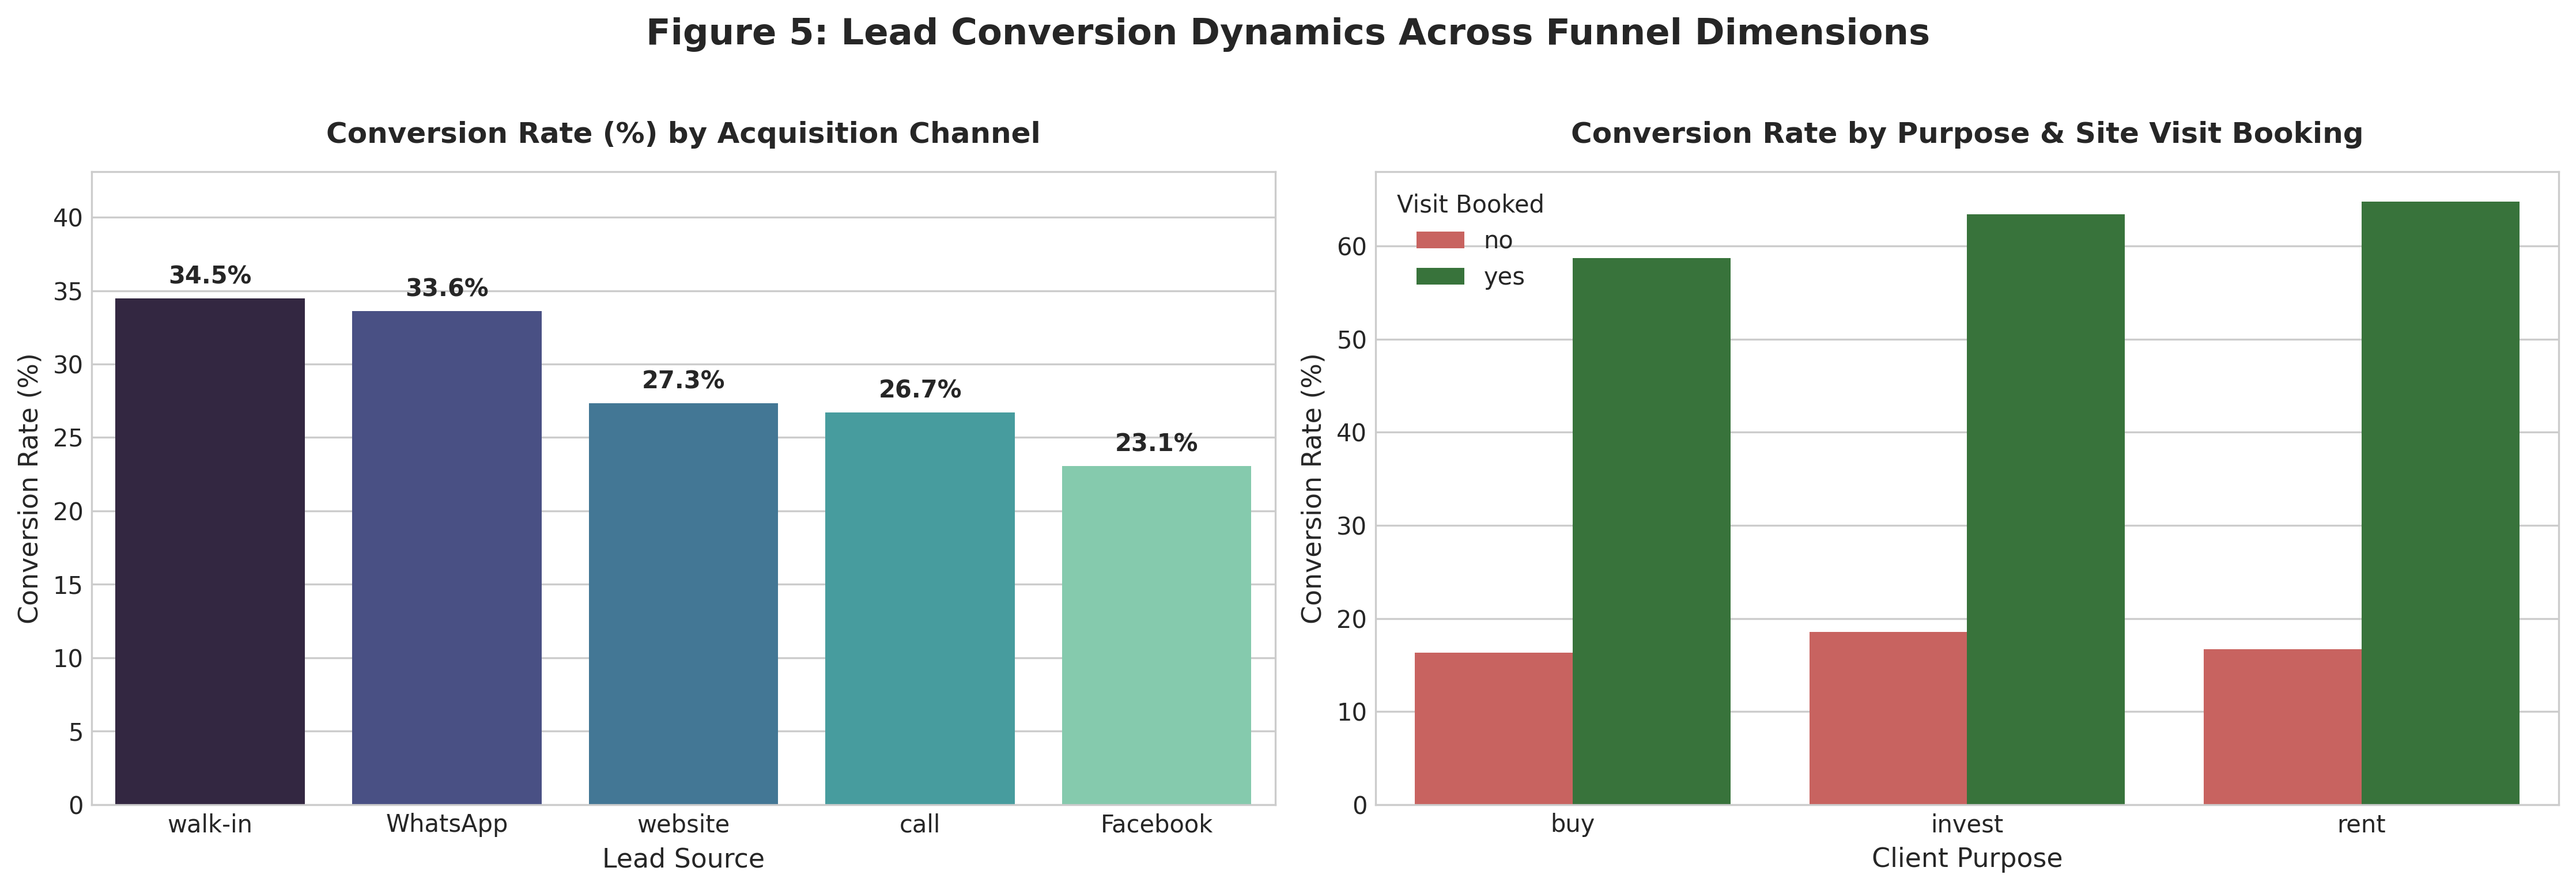

In [5]:
display(Image(filename="../eda/figures/lead_conversion_by_source_purpose.png"))
print("Business Insight: Securing an on-site property visit increases conversion likelihood by over 700%, proving that voice agents and sales reps should focus 100% of their initial call on booking a physical visit.")

### 5. Task 4: Feature Engineering
13 Domain-informed features engineered across properties and leads.

In [6]:
df_prop_feat = pd.read_csv(PROPERTIES_FEATURED_PATH)
df_leads_feat = pd.read_csv(LEADS_FEATURED_PATH)
print("Properties New Features:", [c for c in df_prop_feat.columns if c not in df_prop_clean.columns])
print("Leads New Features:", [c for c in df_leads_feat.columns if c not in df_leads_clean.columns])

Properties New Features: ['price_per_marla', 'property_age_bucket', 'society_tier', 'amenity_score', 'accessibility_composite', 'spatial_density_ratio', 'bed_to_bath_ratio', 'society_hist_median_ppm']
Leads New Features: ['lead_engagement_score', 'response_speed_category', 'budget_to_market_ratio', 'lead_velocity', 'high_intent_flag']


### 6. Task 5: Encoding Strategy Comparison & Scikit-learn Pipeline
- Comparing One-Hot Encoding vs Target Encoding on high-cardinality locations
- 70/15/15 train/val/test splits (stratified for leads)
- Strict data leakage isolation

In [7]:
X_p, y_p, prop_leaks = audit_and_prepare_properties(df_prop_feat)
X_tr_p, X_va_p, X_te_p, y_tr_p, y_va_p, y_te_p = split_property_data(X_p, y_p)
prop_results = compare_property_encoding_strategies(X_tr_p, y_tr_p, X_va_p, y_va_p)
print("Property Encoding Comparison:")
for enc, res in prop_results.items():
    print(f"  {enc.upper()}: Features={res['feature_dimension']}, Val MAE={res['mae_lac']:.2f} Lac PKR, Val R²={res['validation_r2']:.4f}")

X_l, y_l, lead_leaks = audit_and_prepare_leads(df_leads_feat)
X_tr_l, X_va_l, X_te_l, y_tr_l, y_va_l, y_te_l = split_lead_data(X_l, y_l)
lead_results = compare_lead_encoding_strategies(X_tr_l, y_tr_l, X_va_l, y_va_l)
print("\nLead Encoding Comparison:")
for enc, res in lead_results.items():
    print(f"  {enc.upper()}: Features={res['feature_dimension']}, Val ROC-AUC={res['validation_roc_auc']:.4f}, Val F1={res['validation_f1']:.4f}")

Property Encoding Comparison:
  TARGET: Features=31, Val MAE=83.80 Lac PKR, Val R²=0.8074
  ONEHOT: Features=65, Val MAE=84.79 Lac PKR, Val R²=0.8052

Lead Encoding Comparison:
  TARGET: Features=29, Val ROC-AUC=0.8121, Val F1=0.5703
  ONEHOT: Features=63, Val ROC-AUC=0.8049, Val F1=0.5681


C:\Users\PMYLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.16753e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
